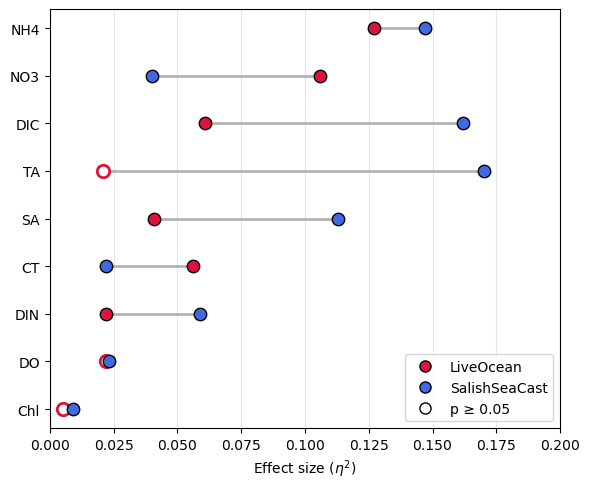

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Variables in desired order
variables = ['NH4','NO3','DIC','TA','SA','CT','DIN','DO','Chl']

# eta² values
eta_lo = np.array([0.127,0.106,0.061,0.021,0.041,0.056,0.022,0.022,0.005])
eta_ssc = np.array([0.147,0.040,0.162,0.170,0.113,0.022,0.059,0.023,0.009])

# p-values (used to indicate significance)
p_lo = np.array([
    5.557e-71,
    7.702e-20,
    6.158e-05,
    7.057e-02,
    6.898e-08,
    3.612e-19,
    4.840e-08,
    7.230e-02,
    2.127e-01
])

p_ssc = np.array([
    1.933e-80,
    2.856e-19,
    2.929e-18,
    3.774e-20,
    4.203e-23,
    1.068e-06,
    5.576e-31,
    2.749e-04,
    2.340e-02
])

y = np.arange(len(variables))

fig, ax = plt.subplots(figsize=(6,5))

# connect models
for i in range(len(y)):
    ax.plot([eta_lo[i], eta_ssc[i]],
            [y[i], y[i]],
            color='0.7',
            lw=2,
            zorder=1)

# LiveOcean markers
for i in range(len(y)):
    if p_lo[i] < 0.05:
        ax.scatter(eta_lo[i], y[i],
                   s=80,
                   color='crimson',
                   edgecolor='k',
                   zorder=3)
    else:
        ax.scatter(eta_lo[i], y[i],
                   s=80,
                   facecolors='white',
                   edgecolors='crimson',
                   linewidth=2,
                   zorder=3)

# SSC markers
for i in range(len(y)):
    if p_ssc[i] < 0.05:
        ax.scatter(eta_ssc[i], y[i],
                   s=80,
                   color='royalblue',
                   edgecolor='k',
                   zorder=3)
    else:
        ax.scatter(eta_ssc[i], y[i],
                   s=80,
                   facecolors='white',
                   edgecolors='royalblue',
                   linewidth=2,
                   zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(variables)
ax.invert_yaxis()   # highest eta² at top

ax.set_xlabel(r'Effect size ($\eta^2$)')
ax.set_xlim(0,0.20)

ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.lines import Line2D

legend = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='crimson', markeredgecolor='k',
           markersize=8, label='LiveOcean'),

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='royalblue', markeredgecolor='k',
           markersize=8, label='SalishSeaCast'),

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='white', markeredgecolor='k',
           markersize=8, label='p ≥ 0.05')
]

ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.show()